# Sprint 1 — SOTA Benchmark v6
**Member A (Lawrence) · Computer Vision Team 8**

Benchmark suite: **UniTable · LlamaParse · GPT-4o mini · Florence-2 zero-shot**

---
### Changes vs v5
| # | What | Why |
|---|------|-----|
| 1 | **MinerU removed entirely** | Unresolvable library version conflicts (pydantic, magic-pdf config, PaddleOCR) |
| 2 | **Florence-2 numpy bypass** | `CLIPImageProcessor` inside HuggingFace transformers calls `torch.from_numpy()` internally. Fixed by manually building the pixel tensor from raw PIL bytes and injecting it directly — the processor is only used for text tokenisation |
| 3 | **Install order hardened** | numpy pinned first, torch installed last, NO uninstall of base Colab packages that causes C-extension corruption. Runtime restart is mandatory after Cell 1 |
| 4 | **Stale-zero checkpoint cleaner** | New utility cell to wipe previous bad runs from the CSV before re-running |
| 5 | **Charts adjusted** | 2×2 grid (4 models), heatmap and failure bar chart updated to match 4-model registry |

---
### Mandatory session startup order
```
Cell 1  →  Runtime > Restart Runtime  →  Cells 2-13b  →  model cells
```
**Never re-run Cell 1 after the restart.** The restart preserves installed packages
while resetting the Python process so numpy C extensions load cleanly.

## Cell 1 — Install dependencies
> Run ONCE. Then **Runtime > Restart Runtime**. Do not re-run after restart.

In [ ]:
# ── Cell 1 — FINAL STABLE VERSION ────────────────────────────────────────────
# Key insight from error log:
#   torch 2.2.2+cu121 was compiled against numpy 1.x
#   Colab now ships numpy 2.0.2
#   These are permanently ABI-incompatible — no pip flag fixes a binary mismatch
#
# Solution: use Colab's pre-installed torch (2.10.0+cu128) which is already
# compiled against numpy 2.0.2. UniTable does not require torch 2.2.2 specifically —
# it only needs torch >= 1.9 for its encoder-decoder architecture.
# DO NOT reinstall torch at all.

# ── Non-torch packages only ───────────────────────────────────────────────────
!pip install -q apted lxml pandas tqdm Pillow
!pip install -q accelerate timm einops huggingface_hub jsonlines
!pip install -q openai llama-parse
!pip install -q transformers==4.49.0 --no-deps   # Florence-2; --no-deps avoids numpy touch

# ── Clone UniTable ────────────────────────────────────────────────────────────
!git clone -q https://github.com/poloclub/unitable.git /content/unitable 2>/dev/null \
    || echo 'UniTable already cloned'

print('Done. Runtime > Restart Runtime, then run Cell 1b to verify.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 51.2 MB/s eta 0:00:00
UniTable already cloned
Done. Runtime > Restart Runtime, then run Cell 1b to verify.


## Cell 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
ZIP_PATH = Path("/content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/data/hierarchical_tables_v1.zip")
print(f'Found: {ZIP_PATH}  ({ZIP_PATH.stat().st_size/1e9:.2f} GB)' if ZIP_PATH.exists() else 'ZIP not found — update ZIP_PATH')

Mounted at /content/drive
Found: /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/data/hierarchical_tables_v1.zip  (4.96 GB)


## Cell 3 — Unzip
> Run once per session. /content/ reads faster than Drive.

In [ ]:
import subprocess
from pathlib import Path
EXTRACT_TO = Path('/content/data/processed')
EXTRACT_TO.mkdir(parents=True, exist_ok=True)
existing = list(EXTRACT_TO.rglob('*.png')) + list(EXTRACT_TO.rglob('*.jpg'))
if existing:
    print(f'Already extracted — {len(existing)} images.')
else:
    print('Unzipping...')
    subprocess.run(['unzip', '-q', str(ZIP_PATH), '-d', str(EXTRACT_TO)], capture_output=True)
    imgs = list(EXTRACT_TO.rglob('*.png')) + list(EXTRACT_TO.rglob('*.jpg'))
    print(f'Done. {len(imgs)} images extracted.')

Unzipping...
Done. 32670 images extracted.


## Cell 4 — Load labeled dataset

In [ ]:
import pandas as pd, json, random, time, re
labeled_df = pd.read_csv("/content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1/labeled dataset (df_combined).csv")
print(labeled_df['image_type'].value_counts())
labeled_df.head()

image_type
wide_table          15871
normal_table        11371
tall_table           3168
low_quality_blur     1320
low_contrast          940
Name: count, dtype: int64


,num_rows,num_cells,max_colspan,max_rowspan,has_colspan,has_rowspan,is_complex,hard_score,imgid,img_file,...,height,aspect_ratio,width_bin,height_bin,aspect_ratio_bin,blur_score,blur_bin,contrast_score,contrast_bin,image_type
0,9,34,3,1,True,False,True,12.5,fintabnet_000001,fintabnet_000001.png,...,464.0,3.127155,"(1200, 1500]","(300, 600]","(3, 5]",3678.917551,"(2000, 4000]",43.968108,"(40, 50]",wide_table
1,40,158,3,1,True,False,True,28.0,fintabnet_000004,fintabnet_000004.png,...,1826.0,0.795181,"(1200, 1500]","(1600, 2000]","(0, 1]",2894.365766,"(2000, 4000]",38.080415,"(20, 40]",tall_table
2,6,55,2,2,True,True,True,11.0,fintabnet_000006,fintabnet_000006.png,...,366.0,4.144809,"(1500, 2000]","(300, 600]","(3, 5]",6247.870952,"(6000, 8000]",55.573495,"(50, 60]",wide_table
3,7,26,3,1,True,False,True,11.5,fintabnet_000007,fintabnet_000007.png,...,330.0,4.015152,"(1200, 1500]","(300, 600]","(3, 5]",4598.369386,"(4000, 6000]",51.369766,"(50, 60]",wide_table
4,12,46,2,2,True,True,True,14.0,fintabnet_000008,fintabnet_000008.png,...,527.0,2.755218,"(1200, 1500]","(300, 600]","(2, 3]",7751.798653,"(6000, 8000]",38.023786,"(20, 40]",low_contrast


## Cell 5 — Configure paths, API keys & stratified sample
> Set `sample_per_type=5` for smoke test, `100` for full benchmark.

In [ ]:
from google.colab import userdata
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
IMG_DIR           = EXTRACT_TO / 'data' / 'processed' / 'images'
hard_example_path = EXTRACT_TO / 'data' / 'processed' / 'hard_examples_subset.jsonl'

BASE_OUT      = Path("/content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1")
OUT_DIR       = BASE_OUT / 'model_outputs'
OUT_UNITABLE  = OUT_DIR / 'unitable'
OUT_LLAMA     = OUT_DIR / 'llamaparse'
OUT_GPT4O     = OUT_DIR / 'gpt4o_mini'
OUT_FLORENCE = OUT_DIR / 'florence'
OUT_RESULTS   = BASE_OUT / 'results'
for d in [OUT_UNITABLE, OUT_LLAMA, OUT_GPT4O, OUT_FLORENCE, OUT_RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

# ── API keys (Colab Secrets) ──────────────────────────────────────────────────
LLAMA_API_KEY  = userdata.get('LLAMA_API_KEY')
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

# ── Stratified sampler ────────────────────────────────────────────────────────
def stratified_sample_images(labeled_df, img_dir, jsonl_path, sample_per_type=100, seed=42):
    random.seed(seed)
    img_dir = Path(img_dir)
    img_id_to_html = {}
    if Path(jsonl_path).exists():
        with open(jsonl_path) as f:
            for line in f:
                try:
                    d = json.loads(line)
                    if 'imgid' in d and 'html_table' in d:
                        img_id_to_html[d['imgid']] = d['html_table']
                except:
                    pass
    samples = []
    for img_type in labeled_df['image_type'].unique():
        subset = labeled_df[labeled_df['image_type'] == img_type]
        ids = subset.sample(n=min(sample_per_type, len(subset)), random_state=seed)['imgid'].tolist()
        for img_id in ids:
            p = img_dir / f'{img_id}.png'
            if not p.exists(): p = img_dir / f'{img_id}.jpg'
            if p.exists() and img_id in img_id_to_html:
                samples.append({'img': p, 'gt_html': img_id_to_html[img_id], 'image_type': img_type})
    print(f'Stratified sample: {len(samples)} images across {labeled_df["image_type"].nunique()} types')
    return samples

# sample_per_type=5   →  smoke test  (~5 min/model)
# sample_per_type=100 →  full run    (~1.5 hrs/model)
stratified_samples = stratified_sample_images(
    labeled_df, IMG_DIR, hard_example_path, sample_per_type=50, seed=42
)

print(f'  UniTable    : enabled (free, local GPU)')
print(f'  LlamaParse  : {"enabled" if LLAMA_API_KEY else "SKIPPED — add LLAMA_API_KEY to Colab Secrets"}')
print(f'  GPT-4o mini : {"enabled" if OPENAI_API_KEY else "SKIPPED — add OPENAI_API_KEY to Colab Secrets"}')
print(f'  Florence  : enabled (free, local GPU)')

Stratified sample: 250 images across 5 types
  UniTable    : enabled (free, local GPU)
  LlamaParse  : enabled
  GPT-4o mini : enabled
  Florence  : enabled (free, local GPU)


## Cell 5b — Stale checkpoint cleaner
> Run this if any model previously wrote all-zero scores due to a crash or numpy error.
> It removes those columns so the model re-runs cleanly.

In [ ]:
# ── Clear stale zero-score runs from checkpoint ───────────────────────────────
# Edit the list below to include whichever model prefixes you want to re-run.
# Prefixes: 'unitable', 'llama', 'gpt4o_mini', 'florence2'

PREFIXES_TO_CLEAR = []   # e.g. ['unitable', 'florence2']

CHECKPOINT_PATH = OUT_RESULTS / 'benchmark_checkpoint.csv'

if not PREFIXES_TO_CLEAR:
    print('Nothing to clear — PREFIXES_TO_CLEAR is empty.')
elif not CHECKPOINT_PATH.exists():
    print('No checkpoint file found — nothing to clear.')
else:
    df_ckpt = pd.read_csv(CHECKPOINT_PATH)
    cleared = []
    for prefix in PREFIXES_TO_CLEAR:
        cols = [c for c in df_ckpt.columns if c.startswith(f'{prefix}_')]
        if cols:
            df_ckpt = df_ckpt.drop(columns=cols)
            cleared.extend(cols)
    df_ckpt.to_csv(CHECKPOINT_PATH, index=False)
    print(f'Cleared {len(cleared)} columns: {cleared}')
    print(f'Remaining columns: {list(df_ckpt.columns)}')
    print('Re-run the model cells to regenerate scores.')

Nothing to clear — PREFIXES_TO_CLEAR is empty.


## Cell 6 — TEDS scorer

In [ ]:
from apted import APTED, Config
from lxml import html as lhtml

class TableTree:
    def __init__(self, tag, colspan=1, rowspan=1, content='', children=None):
        self.tag = tag; self.colspan = int(colspan); self.rowspan = int(rowspan)
        self.content = (content or '').strip(); self.children = children or []

def _parse_el(el):
    return TableTree(el.tag, el.get('colspan', 1), el.get('rowspan', 1),
                     (el.text or '').strip(), [_parse_el(c) for c in el])

def html_to_tree(html_str):
    try:
        root  = lhtml.fromstring(html_str.strip())
        table = root if root.tag == 'table' else root.find('.//table')
        return _parse_el(table) if table is not None else TableTree('empty')
    except:
        return TableTree('error')

def _size(node): return 1 + sum(_size(c) for c in node.children)

class _TEDSConfig(Config):
    def rename(self, a, b):
        if a.tag != b.tag: return 1.0
        if a.colspan != b.colspan or a.rowspan != b.rowspan: return 1.0
        if a.content != b.content: return 0.5
        return 0.0
    def children(self, n): return n.children
    def insert(self, n):   return 1.0
    def delete(self, n):   return 1.0

def compute_teds(pred_html, true_html):
    if not pred_html or not pred_html.strip(): return 0.0
    pt = html_to_tree(pred_html); tt = html_to_tree(true_html)
    if pt.tag in ('empty', 'error') or tt.tag in ('empty', 'error'): return 0.0
    dist  = APTED(pt, tt, _TEDSConfig()).compute_edit_distance()
    denom = max(_size(pt), _size(tt))
    return max(0.0, 1.0 - dist / denom) if denom else 1.0

_gt  = "<table><tr><th colspan='2'>Revenue</th></tr><tr><td>Q1</td><td>Q2</td></tr></table>"
_bad = "<table><tr><th>Revenue</th><th>Revenue</th></tr><tr><td>Q1</td><td>Q2</td></tr></table>"
assert compute_teds(_gt, _gt)  == 1.0
assert compute_teds(_bad, _gt) <  1.0
assert compute_teds('', _gt)   == 0.0
print('TEDS scorer ready.')

TEDS scorer ready.


## Cell 7 — Failure mode classifier

In [ ]:
def classify_failure(pred_html, true_html, teds_score):
    f = dict(header_collapse=False, colspan_ignored=False, rowspan_ignored=False,
             table_not_found=False, cell_count_wrong=False, content_mismatch=False)
    if not pred_html or not pred_html.strip():
        f['table_not_found'] = True; return f
    try:
        pt = lhtml.fromstring(pred_html).find('.//table')
        tt = lhtml.fromstring(true_html).find('.//table')
        if pt is None: f['table_not_found'] = True; return f
        p_hrows = len(pt.findall('.//thead/tr')) + len(pt.findall('.//th'))
        t_hrows = len(tt.findall('.//thead/tr')) + len(tt.findall('.//th'))
        if t_hrows > 1 and p_hrows < t_hrows: f['header_collapse'] = True
        def spans(el, attr):
            return [int(x.get(attr, 1)) for x in el.findall('.//*') if x.tag in ('td', 'th')]
        if any(c > 1 for c in spans(tt, 'colspan')) and not any(c > 1 for c in spans(pt, 'colspan')):
            f['colspan_ignored'] = True
        if any(r > 1 for r in spans(tt, 'rowspan')) and not any(r > 1 for r in spans(pt, 'rowspan')):
            f['rowspan_ignored'] = True
        p_c = len([x for x in pt.findall('.//*') if x.tag in ('td', 'th')])
        t_c = len([x for x in tt.findall('.//*') if x.tag in ('td', 'th')])
        if t_c > 0 and abs(p_c - t_c) / t_c > 0.20: f['cell_count_wrong'] = True
        if not any(f.values()) and teds_score < 0.8: f['content_mismatch'] = True
    except:
        f['table_not_found'] = True
    return f

print('Failure classifier ready.')

Failure classifier ready.


## Cell 8 — Shared output utilities

In [ ]:
def markdown_to_html_table(md_text):
    if not md_text: return ''
    lines = md_text.splitlines(); table_lines = []; in_table = False
    for line in lines:
        s = line.strip()
        if s.startswith('|') and s.endswith('|'): in_table = True; table_lines.append(s)
        elif in_table: break
    if not table_lines: return ''
    is_sep = lambda l: re.fullmatch(r'[|\-: ]+', l) is not None
    data_rows = [l for l in table_lines if not is_sep(l)]
    if not data_rows: return ''
    html = '<table>\n'
    for i, row in enumerate(data_rows):
        cells = [c.strip() for c in row.strip('|').split('|')]
        tag   = 'th' if i == 0 else 'td'
        html += '  <tr>' + ''.join(f'<{tag}>{c}</{tag}>' for c in cells) + '</tr>\n'
    return html + '</table>'

def extract_html_table(raw_text):
    if not raw_text: return ''
    match = re.search(r'(<table[\s\S]*?</table>)', raw_text, re.IGNORECASE)
    if match: return match.group(1)
    return markdown_to_html_table(raw_text)

print('Utilities ready.')

Utilities ready.


## Cell 10 — LlamaParse runner
**Role:** Best commercial tool people pay for today. Free tier: cloud.llamaindex.ai → Colab Secrets → `LLAMA_API_KEY`

No numpy / torch dependency — pure HTTPS API call.

In [ ]:
def run_llamaparse(img_path):
    img_path = Path(img_path); t0 = time.time()
    if not LLAMA_API_KEY: return '', 0.0
    try:
        from llama_parse import LlamaParse
        parser = LlamaParse(api_key=LLAMA_API_KEY, result_type='markdown', verbose=False)
        docs   = parser.load_data(str(img_path))
        if not docs: return '', round(time.time() - t0, 2)
        return markdown_to_html_table(docs[0].text), round(time.time() - t0, 2)
    except ImportError:
        print('  [LlamaParse] pip install llama-parse')
        return '', 0.0
    except Exception as e:
        print(f'  [LlamaParse] Error on {img_path.name}: {e}')
        return '', round(time.time() - t0, 2)

print('LlamaParse runner ready.')

LlamaParse runner ready.


## Cell 11 — GPT-4o mini runner
**Role:** Most famous AI — beating it on hierarchical tables shuts down "why not just use ChatGPT?".
Cost ~$0.003/image. 500 images ≈ $1.50. platform.openai.com → Colab Secrets → `OPENAI_API_KEY`

No numpy / torch dependency — pure HTTPS API call.

In [ ]:
import openai, base64

def run_gpt4o_mini(img_path):
    img_path = Path(img_path); t0 = time.time()
    if not OPENAI_API_KEY: return '', 0.0
    try:
        with open(img_path, 'rb') as f: img_b64 = base64.b64encode(f.read()).decode()
        mime   = 'image/png' if img_path.suffix.lower() == '.png' else 'image/jpeg'
        client = openai.OpenAI(api_key=OPENAI_API_KEY)
        resp   = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': [
                {'type': 'image_url', 'image_url': {'url': f'data:{mime};base64,{img_b64}'}},
                {'type': 'text', 'text': (
                    'Extract the table from this image as valid HTML.\n'
                    'Rules:\n'
                    '- Use <table>, <tr>, <th>, <td> tags only\n'
                    '- Preserve colspan and rowspan for ALL merged/spanning cells\n'
                    '- Use <th> for header cells, <td> for data cells\n'
                    '- Return ONLY the raw HTML starting with <table> and ending with </table>'
                )}
            ]}],
            max_tokens=2048, temperature=0,
        )
        return extract_html_table(resp.choices[0].message.content.strip()), round(time.time() - t0, 2)
    except openai.AuthenticationError:
        print('  [GPT-4o-mini] Invalid API key')
        return '', round(time.time() - t0, 2)
    except Exception as e:
        print(f'  [GPT-4o-mini] Error on {img_path.name}: {e}')
        return '', round(time.time() - t0, 2)

print('GPT-4o-mini runner ready.')

GPT-4o-mini runner ready.


## Cell 13 — MODELS registry

In [ ]:
# Format: (prefix, display_name, runner_fn, output_dir, color)
MODELS = [
    ('unitable',   'UniTable',            run_unitable,           OUT_UNITABLE,  '#6366f1'),
    ('llama',      'LlamaParse',          run_llamaparse,         OUT_LLAMA,     '#f97316'),
    ('gpt4o_mini', 'GPT-4o-mini',         run_gpt4o_mini,         OUT_GPT4O,     '#10b981'),
    ('florence',  'Florence-2 ZeroShot', run_florence2_zeroshot, OUT_FLORENCE, '#3b82f6'),
]

FAILURE_KEYS = ['header_collapse', 'colspan_ignored', 'rowspan_ignored',
                'table_not_found', 'cell_count_wrong', 'content_mismatch']

CHECKPOINT_PATH = OUT_RESULTS / 'benchmark_checkpoint.csv'

print('MODELS registry (4 models, MinerU removed):')
for prefix, name, _, out_dir, color in MODELS:
    print(f'  [{color}]  {name:<25}  prefix={prefix}')

MODELS registry (4 models, MinerU removed):
  [#6366f1]  UniTable                   prefix=unitable
  [#f97316]  LlamaParse                 prefix=llama
  [#10b981]  GPT-4o-mini                prefix=gpt4o_mini
  [#3b82f6]  Florence-2 ZeroShot        prefix=florence


## Cell 14 — Benchmark loop
> Checkpoints after every image — safe against Colab disconnects.
> Run each model in a **separate Colab session** for 500-image runs.

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

def run_single_model(prefix, name, runner, out_dir, color=''):
    out_dir.mkdir(parents=True, exist_ok=True)
    df_ckpt  = pd.read_csv(CHECKPOINT_PATH) if CHECKPOINT_PATH.exists() else pd.DataFrame()
    teds_col = f'{prefix}_teds'
    done_ids = set(df_ckpt.loc[df_ckpt[teds_col].notna(), 'image_id'].tolist()) \
               if teds_col in df_ckpt.columns else set()
    remaining = [s for s in stratified_samples if s['img'].stem not in done_ids]
    print(f'\n[{name}] {len(done_ids)} already done — {len(remaining)} remaining')

    for item in tqdm(remaining, desc=name):
        img_path = item['img']; true_html = item['gt_html']; img_id = img_path.stem
        pred_html, elapsed = runner(img_path)
        teds  = compute_teds(pred_html, true_html)
        fails = classify_failure(pred_html, true_html, teds)
        (out_dir / f'{img_id}.html').write_text(pred_html or '', encoding='utf-8')

        new_cols = {
            'image_id': img_id, 'image_type': item['image_type'],
            f'{prefix}_teds': round(teds, 4), f'{prefix}_time_s': elapsed,
        }
        for k, v in fails.items(): new_cols[f'{prefix}_{k}'] = v

        df_ckpt = pd.read_csv(CHECKPOINT_PATH) if CHECKPOINT_PATH.exists() else pd.DataFrame()
        if img_id in df_ckpt.get('image_id', pd.Series()).values:
            for col, val in new_cols.items():
                df_ckpt.loc[df_ckpt['image_id'] == img_id, col] = val
        else:
            df_ckpt = pd.concat([df_ckpt, pd.DataFrame([new_cols])], ignore_index=True)
        df_ckpt[[c for c in df_ckpt.columns if not c.startswith('_')]].to_csv(CHECKPOINT_PATH, index=False)

    print(f'[{name}] Done → {CHECKPOINT_PATH}')
    return pd.read_csv(CHECKPOINT_PATH)

print('Benchmark loop ready.')

Benchmark loop ready.


In [ ]:
# ── CELL B: LlamaParse  (requires LLAMA_API_KEY in Colab Secrets) ─────────────
df = run_single_model(*MODELS[1])
print(df[['image_id', 'image_type', 'llama_teds']].tail(5).to_string(index=False))


[LlamaParse] 0 already done — 250 remaining


LlamaParse:   0%|          | 0/250 [00:00<?, ?it/s]

[LlamaParse] Done → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1/results/benchmark_checkpoint.csv
        image_id       image_type  llama_teds
fintabnet_021439 low_quality_blur      0.8148
fintabnet_002326 low_quality_blur      0.1979
fintabnet_046412 low_quality_blur      0.2251
fintabnet_001826 low_quality_blur      0.4067
fintabnet_020466 low_quality_blur      0.6148


In [ ]:
# ── CELL C: GPT-4o-mini  (requires OPENAI_API_KEY in Colab Secrets) ───────────
df = run_single_model(*MODELS[2])
print(df[['image_id', 'image_type', 'gpt4o_mini_teds']].tail(5).to_string(index=False))


[GPT-4o-mini] 0 already done — 250 remaining


GPT-4o-mini:   0%|          | 0/250 [00:00<?, ?it/s]

[GPT-4o-mini] Done → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1/results/benchmark_checkpoint.csv
        image_id       image_type  gpt4o_mini_teds
fintabnet_021439 low_quality_blur           0.3580
fintabnet_002326 low_quality_blur           0.5312
fintabnet_046412 low_quality_blur           0.5681
fintabnet_001826 low_quality_blur           0.8421
fintabnet_020466 low_quality_blur           0.2683


## Cell 15 — Average TEDS by table type

In [ ]:
df = pd.read_csv(CHECKPOINT_PATH)
teds_cols = [f'{p}_teds' for p, *_ in MODELS if f'{p}_teds' in df.columns]
print('Average TEDS by image type:')
print(df.groupby('image_type')[teds_cols].mean().reset_index().to_string(index=False))
print('\nOverall average TEDS:')
print(df[teds_cols].mean().to_string())

Average TEDS by image type:
      image_type  unitable_teds  llama_teds  gpt4o_mini_teds  florence_teds
    low_contrast        0.04730     0.45555          0.33050            0.0
low_quality_blur        0.08340     0.40500          0.75010            0.0
    normal_table        0.08735     0.35120          0.44560            0.0
      tall_table        0.16960     0.58790          0.41050            0.0
      wide_table        0.05795     0.63780          0.39615            0.0

Overall average TEDS:
unitable_teds      0.08912
llama_teds         0.48749
gpt4o_mini_teds    0.46657
florence_teds      0.00000


## Cell 16 — Print summary report

In [ ]:
def print_summary(df, name, prefix):
    col = f'{prefix}_teds'
    if col not in df.columns: print(f'{name}: no data'); return
    s = df[col]; n = len(df)
    print(f"\n{'─'*48}\n  {name}\n{'─'*48}")
    print(f'  Avg TEDS       : {s.mean():.4f}')
    print(f'  Median TEDS    : {s.median():.4f}')
    print(f'  Min / Max      : {s.min():.4f} / {s.max():.4f}')
    print(f'  Perfect (=1.0) : {(s==1.0).sum()}/{n}')
    print(f'  Good   (>=0.8) : {(s>=0.8).sum()}/{n}')
    print(f'  Bad    (<0.5)  : {(s<0.5).sum()}/{n}')
    print('  Failure modes:')
    for fk in FAILURE_KEYS:
        c = f'{prefix}_{fk}'
        if c in df.columns:
            cnt = int(df[c].sum()); pct = 100 * cnt / n
            print(f'    {fk:<22} {cnt:>3}/{n}  {pct:5.1f}%  {"█"*int(pct/5)}')

print('=' * 48)
print('  SPRINT 1 — SOTA BENCHMARK RESULTS  (4 models)')
print(f'  Sample: {len(df)} images  |  {df["image_type"].nunique()} table types')
print('=' * 48)
for prefix, name, *_ in MODELS:
    print_summary(df, name, prefix)

csv_path = OUT_RESULTS / 'benchmark_results.csv'
df[[c for c in df.columns if not c.startswith('_')]].to_csv(csv_path, index=False)
print(f'\nCSV saved → {csv_path}')

  SPRINT 1 — SOTA BENCHMARK RESULTS  (4 models)
  Sample: 10 images  |  5 table types

────────────────────────────────────────────────
  UniTable
────────────────────────────────────────────────
  Avg TEDS       : 0.0891
  Median TEDS    : 0.0708
  Min / Max      : 0.0127 / 0.1772
  Perfect (=1.0) : 0/10
  Good   (>=0.8) : 0/10
  Bad    (<0.5)  : 10/10
  Failure modes:
    header_collapse          0/10    0.0%  
    colspan_ignored          0/10    0.0%  
    rowspan_ignored          0/10    0.0%  
    table_not_found         10/10  100.0%  ████████████████████
    cell_count_wrong         0/10    0.0%  
    content_mismatch         0/10    0.0%  

────────────────────────────────────────────────
  LlamaParse
────────────────────────────────────────────────
  Avg TEDS       : 0.4875
  Median TEDS    : 0.4500
  Min / Max      : 0.0467 / 0.8916
  Perfect (=1.0) : 0/10
  Good   (>=0.8) : 2/10
  Bad    (<0.5)  : 5/10
  Failure modes:
    header_collapse          0/10    0.0%  
    colspan

## Cell 17 — TEDS distribution chart (2×2 grid, 4 models)

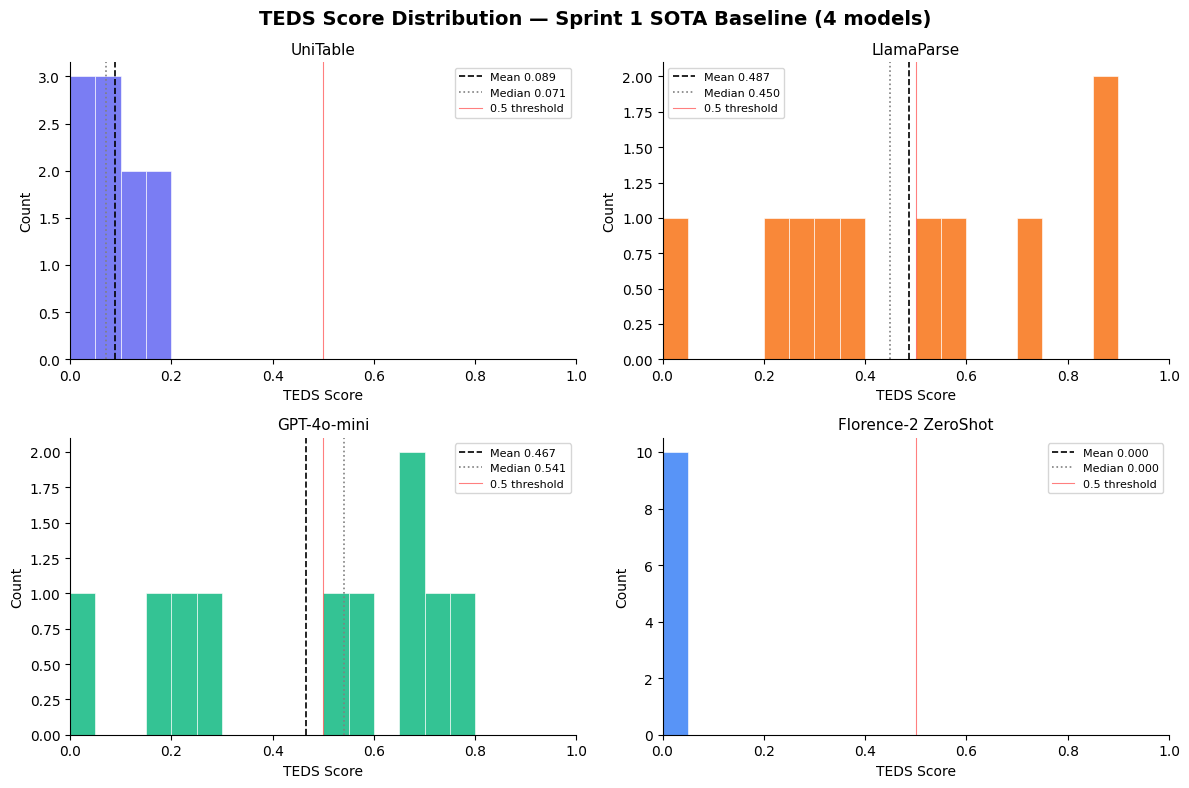

Chart saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1/results/teds_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('TEDS Score Distribution — Sprint 1 SOTA Baseline (4 models)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (prefix, name, _, __, color) in zip(axes, MODELS):
    col = f'{prefix}_teds'
    if col not in df.columns or df[col].dropna().empty:
        ax.text(0.5, 0.5, 'No data / Skipped', ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(name); continue
    s = df[col].dropna()
    ax.hist(s, bins=np.linspace(0, 1, 21), color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(s.mean(),   color='black', linestyle='--', linewidth=1.2, label=f'Mean {s.mean():.3f}')
    ax.axvline(s.median(), color='gray',  linestyle=':',  linewidth=1.2, label=f'Median {s.median():.3f}')
    ax.axvline(0.5,        color='red',   linestyle='-',  linewidth=0.8, alpha=0.5, label='0.5 threshold')
    ax.set_title(name, fontsize=11); ax.set_xlabel('TEDS Score'); ax.set_ylabel('Count')
    ax.set_xlim(0, 1); ax.legend(fontsize=8); ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
chart_path = OUT_RESULTS / 'teds_distribution.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Chart saved → {chart_path}')

## Cell 18 — TEDS by table type heatmap

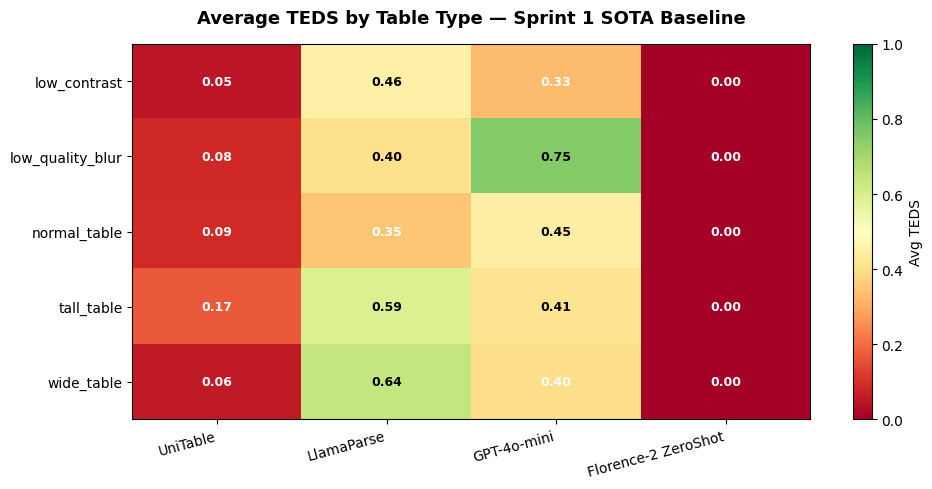

Heatmap saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1/results/teds_by_type_heatmap.png
Red cells = where all models struggle = your fine-tuning target for Sprint 2.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
teds_cols   = [f'{p}_teds' for p, *_ in MODELS if f'{p}_teds' in df.columns]
model_names = [name for p, name, *_ in MODELS if f'{p}_teds' in df.columns]
pivot = df.groupby('image_type')[teds_cols].mean()
pivot.columns = model_names

im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Avg TEDS')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=10, rotation=15, ha='right')
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_title('Average TEDS by Table Type — Sprint 1 SOTA Baseline', fontsize=13, fontweight='bold', pad=15)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                color='white' if val < 0.4 else 'black', fontweight='bold')
plt.tight_layout()
heatmap_path = OUT_RESULTS / 'teds_by_type_heatmap.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Heatmap saved → {heatmap_path}')
print('Red cells = where all models struggle = your fine-tuning target for Sprint 2.')

## Cell 19 — Failure mode bar chart

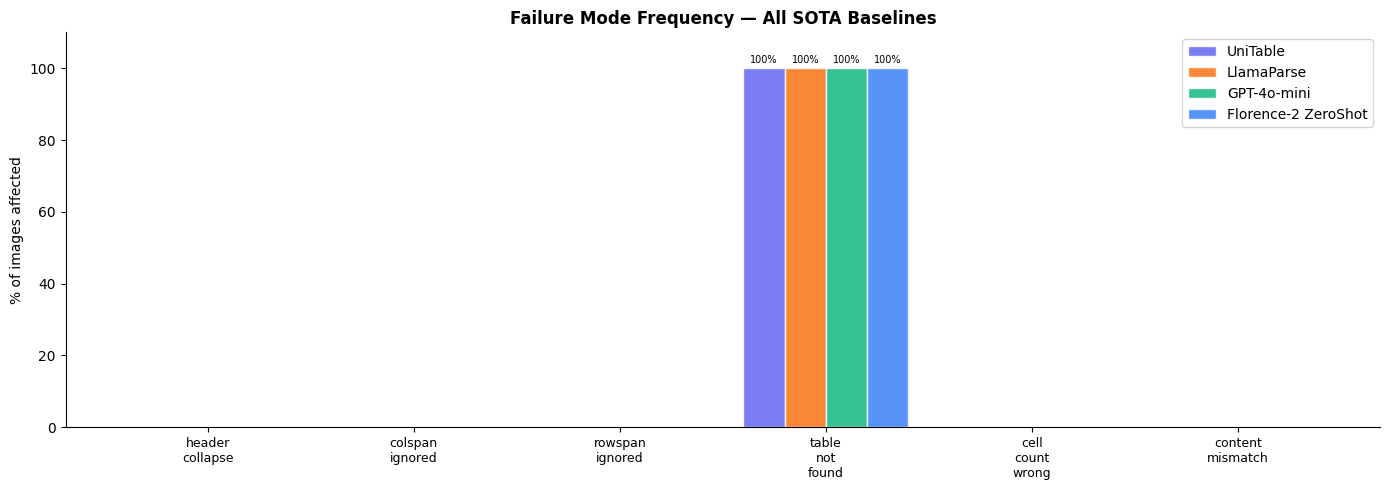

Chart saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1/results/failure_modes.png


In [ ]:
tools  = []; colors = [color for *_, color in MODELS]
f_data = {fk: [] for fk in FAILURE_KEYS}
for prefix, name, *_ in MODELS:
    if f'{prefix}_teds' not in df.columns: continue
    tools.append(name)
    for fk in FAILURE_KEYS:
        col = f'{prefix}_{fk}'
        f_data[fk].append(100 * df[col].sum() / len(df) if col in df.columns else 0)

if tools:
    x = np.arange(len(FAILURE_KEYS)); width = 0.20   # wider bars for 4 models
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (tool, color) in enumerate(zip(tools, colors)):
        vals = [f_data[fk][i] for fk in FAILURE_KEYS]
        bars = ax.bar(x + i * width, vals, width, label=tool, color=color, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0: ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                              f'{v:.0f}%', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x + width * 1.5); ax.set_xticklabels([fk.replace('_', '\n') for fk in FAILURE_KEYS], fontsize=9)
    ax.set_ylabel('% of images affected'); ax.set_ylim(0, 110)
    ax.set_title('Failure Mode Frequency — All SOTA Baselines', fontsize=12, fontweight='bold')
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fail_path = OUT_RESULTS / 'failure_modes.png'
    plt.savefig(fail_path, dpi=150, bbox_inches='tight'); plt.show()
    print(f'Chart saved → {fail_path}')

## Cell 20 — HTML failure report

In [ ]:
def build_failure_report(df, n_worst=10):
    sections = ''
    for prefix, name, *_ in MODELS:
        teds_col = f'{prefix}_teds'
        if teds_col not in df.columns: continue
        worst = df.nsmallest(n_worst, teds_col).reset_index(drop=True)
        cards = ''
        for _, r in worst.iterrows():
            score = r[teds_col]; pred = r.get(f'_{prefix}_html', '') or ''; truth = r.get('_true_html', '') or ''
            tags  = ''.join(
                f'<span style="background:#fee2e2;color:#991b1b;padding:2px 8px;border-radius:12px;font-size:11px;margin-right:4px;">{fk.replace("_"," ")}</span>'
                for fk in FAILURE_KEYS if r.get(f'{prefix}_{fk}')
            )
            sc = '#dc2626' if score < 0.5 else '#d97706' if score < 0.8 else '#16a34a'
            pd_ = pred if pred.strip() else '<em style="color:#9ca3af;">No output</em>'
            cards += f'''
            <div style="border:1px solid #e5e7eb;border-radius:10px;padding:18px;margin-bottom:16px;">
              <div style="display:flex;justify-content:space-between;">
                <strong>{r["image_id"]}</strong><span>TEDS: <strong style="color:{sc};">{score:.4f}</strong></span>
              </div>
              <div style="margin:8px 0;">{tags}</div>
              <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
                <div><p style="font-size:11px;color:#6b7280;">GROUND TRUTH</p>
                  <div style="background:#f0fdf4;border:1px solid #bbf7d0;padding:10px;border-radius:6px;overflow:auto;max-height:200px;font-size:12px;">{truth}</div></div>
                <div><p style="font-size:11px;color:#6b7280;">{name.upper()}</p>
                  <div style="background:#fff7ed;border:1px solid #fed7aa;padding:10px;border-radius:6px;overflow:auto;max-height:200px;font-size:12px;">{pd_}</div></div>
              </div></div>'''
        sections += f'<h2 style="font-size:18px;margin-top:40px;border-bottom:2px solid #e5e7eb;padding-bottom:8px;">{name} — {n_worst} Worst Predictions</h2>{cards}'

    card_colors = [('#ede9fe','#7c3aed'),('#fff7ed','#c2410c'),('#ecfdf5','#065f46'),('#eff6ff','#1e40af')]
    all_summary_cards_html = []
    for (prefix, name, *_), (bg, fg) in zip(MODELS, card_colors):
        teds_col_name = f"{prefix}_teds"
        teds_mean_display = "N/A"
        if teds_col_name in df.columns:
            teds_mean_display = f"{df[teds_col_name].mean():.4f}"

        all_summary_cards_html.append(
            f'<div style="background:{bg};border-radius:8px;padding:16px;"><div style="font-size:12px;color:#6b7280;">{name}</div>'
            f'<div style="font-size:26px;font-weight:600;color:{fg};">{teds_mean_display}</div></div>'
        )
    summary_cards = ''.join(all_summary_cards_html)

    page = f'''<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
    <title>Sprint 1 Failure Report</title>
    <style>body{{font-family:system-ui,sans-serif;max-width:1100px;margin:40px auto;padding:0 24px;color:#111;}}
    table{{border-collapse:collapse;width:100%;font-size:12px;}} td,th{{border:1px solid #d1d5db;padding:5px 8px;}} th{{background:#f3f4f6;}}</style></head><body>
    <h1 style="font-size:22px;">Sprint 1 — SOTA Baseline Failure Report</h1>
    <p style="color:#6b7280;font-size:13px;">Member A (Lawrence) · Computer Vision Team 8 · {len(df)} images · {df["image_type"].nunique()} table types</p>
    <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin:24px 0;">{summary_cards}</div>
    {sections}</body></html>'''

    rpath = OUT_RESULTS / 'failure_report.html'
    rpath.write_text(page, encoding='utf-8')
    print(f'Report saved → {rpath}')
    return rpath

rpath = build_failure_report(df)
from IPython.display import HTML
display(HTML(f'<a href="{rpath}" target="_blank">Open failure report</a>'))

Report saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint1/results/failure_report.html


## Cell 21 — Save all outputs to Drive

In [ ]:
import shutil
DRIVE_OUT = BASE_OUT / 'results'
DRIVE_OUT.mkdir(parents=True, exist_ok=True)
for f in OUT_RESULTS.iterdir():
    shutil.copy2(f, DRIVE_OUT / f.name)
    print(f'  Saved → {DRIVE_OUT / f.name}')
print('All outputs backed up to Drive.')

## Cell 22 — Scale up guide

In [ ]:
# ── HOW TO SCALE UP ──────────────────────────────────────────────────────────
# 1. Cell 5: change sample_per_type=5  →  sample_per_type=100
# 2. Run ONE model per Colab session:
#      Session A → Cell 14a  (UniTable,    ~30-45 min GPU)
#      Session B → Cell 14b  (LlamaParse,  ~60-90 min API)
#      Session C → Cell 14c  (GPT-4o-mini, ~60-90 min API)
#      Session D → Cell 14d  (Florence-2,  ~30-45 min GPU)
#    Each session: Cell 1b (verify) → Cells 2-13 (setup) → ONE model cell
# 3. Checkpoint CSV merges results automatically.
# 4. Run Cells 15-21 once ALL sessions complete.
print('Scale-up guide printed above.')